In [2]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import time 
import seaborn as sns
import matplotlib.pyplot as plt
import liana as li
import itertools

In [5]:
adata = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/dataset.h5ad')

In [5]:
genes = ["LRRK2", "DRD2", "GRK2", "GLP1R"]

In [9]:
# this is to see if those genes actually are presented in the gene names of original data
[g for g in genes if g in adata.var["gene_name"].values]

['LRRK2', 'DRD2', 'GRK2', 'GLP1R']

In [6]:
gene_map = dict(zip(adata.var["gene_name"], adata.var_names))
genes_idx = [gene_map[g] for g in genes if g in gene_map]
adata_sub = adata[:, genes_idx]
adata_sub.var["gene_name"] = genes

/var/tmp/pbs.433065.pbs01/ipykernel_249787/662617938.py:4: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


In [19]:
X = adata_sub.X.toarray() if not isinstance(adata_sub.X, np.ndarray) else adata_sub.X

expr_binary = X > 0

coexpress_all = expr_binary.all(axis=1)

adata.obs["coexpress_all_4"] = coexpress_all

In [27]:
pd.crosstab(
    adata.obs["cell_type"],
    adata.obs["coexpress_all_4"]
)

coexpress_all_4,False,True
cell_type,,
ependymal cell,12559,0
endothelial cell,11070,0
astrocyte,227449,3
oligodendrocyte,1093520,0
GABAergic neuron,152366,27
glutamatergic neuron,328792,64
leukocyte,2361,0
central nervous system macrophage,118515,0
oligodendrocyte precursor cell,112584,1


In [ ]:
# Repeat the analysis 

In [31]:
gene_map = dict(zip(adata_pd.var["gene_name"], adata_pd.var_names))
genes_idx = [gene_map[g] for g in genes if g in gene_map]
adata_sub = adata_pd[:, genes_idx]
adata_sub.var["gene_name"] = genes

/var/tmp/pbs.433065.pbs01/ipykernel_249787/1663796245.py:4: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


In [1]:
X = adata_sub.X.toarray() if not isinstance(adata_sub.X, np.ndarray) else adata_sub.X

expr_binary = X > 0

coexpress_all = expr_binary.all(axis=1)

adata_pd.obs["coexpress_all_4"] = coexpress_all

NameError: name 'adata_sub' is not defined

In [ ]:
pd.crosstab(
    adata_pd.obs["cell_type"],
    adata_pd.obs["coexpress_all_4"]
)

In [10]:
genes_of_interest = ["LRRK2", "DRD2", "GRK2", "GLP1R"]

In [23]:
import scanpy as sc
import pandas as pd

# Define your genes of interest
genes_of_interest = ["LRRK2", "DRD2", "GRK2", "GLP1R"]

# Map gene names to the actual indices in your adata
# This handles the case where var_names are ENSG IDs
ids = adata.var.index[adata.var['gene_name'].isin(genes_of_interest)].tolist()
names = adata.var.loc[ids, 'gene_name'].tolist()
gene_dict = dict(zip(names, ids))

In [30]:
adata_pd

View of AnnData object with n_obs × n_vars = 1650858 × 17267
    obs: 'n_genes', 'n_counts', 'Brain_bank', 'RIN', 'path_braak_lb', 'derived_class2', 'PMI', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'genome', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'uid'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'

In [2]:
# split the data

adata_pd = adata[adata.obs["disease"] == "Parkinson disease"]
adata_ctrl = adata[adata.obs["disease"] == "normal"]

NameError: name 'adata' is not defined

In [17]:
adata_ctrl.obs['disease']

barcodekey
Set10_C1-AAACGCTAGGGCCTCT    normal
Set10_C1-AAACGCTGTGCCTGAC    normal
Set10_C1-AAAGAACAGAACGTGC    normal
Set10_C1-AAAGAACGTATGAGGC    normal
Set10_C1-AAAGAACTCAGTGCGC    normal
                              ...  
set7A_2-TTTGTTGCAGAACATA     normal
set7A_2-TTTGTTGGTATGAGCG     normal
set7A_2-TTTGTTGGTTCTCAGA     normal
set7A_2-TTTGTTGTCAAGAGTA     normal
set7A_2-TTTGTTGTCGCCTATC     normal
Name: disease, Length: 445297, dtype: category
Categories (1, object): ['normal']

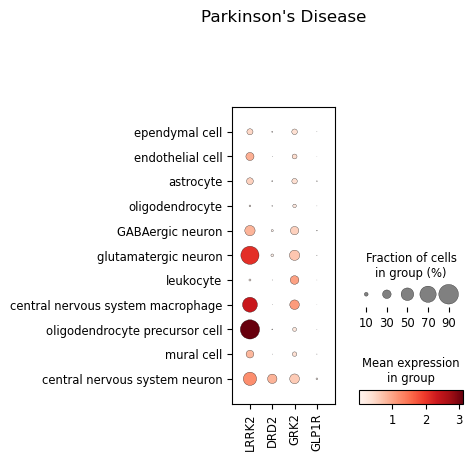

In [12]:
# or do it separately to have more control
# for Parkinson disease 

sc.pl.dotplot(
    adata_pd,
    var_names=genes_of_interest,
    groupby="cell_type",
    gene_symbols="gene_name",
    use_raw=False,
    title="Parkinson's Disease"
)

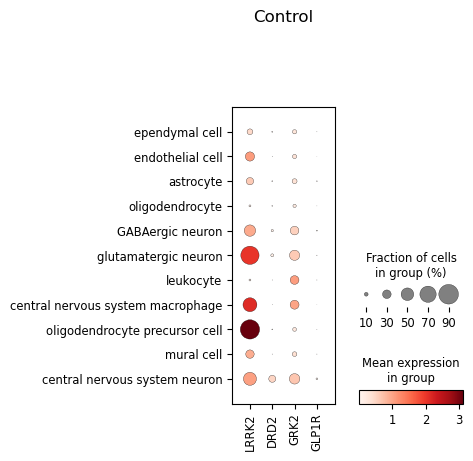

In [13]:
# for control 

sc.pl.dotplot(
    adata_ctrl,
    var_names=genes_of_interest,
    groupby="cell_type",
    gene_symbols="gene_name",
    use_raw=False,
    title="Control"
)

/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 17267 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.


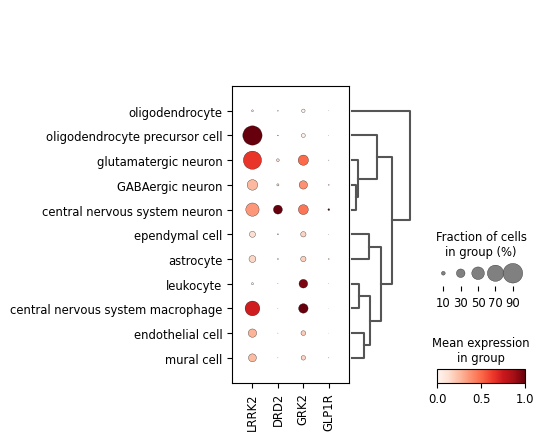

In [30]:
sc.pl.dotplot(
    adata, 
    var_names=genes_of_interest, 
    groupby='cell_type', 
    gene_symbols='gene_name', 
    use_raw=False,      # <--- ADD THIS LINE
    dendrogram=True,
    standard_scale='var'
)

In [36]:
# Check correlation between LRRK2 and the others
for cell in adata.obs['cell_type'].unique():
    print(f"--- Correlation in {cell} ---")
    subset = adata[adata.obs['cell_type'] == cell]
    # Calculate correlation matrix for our 4 genes
    # Note: .X.toarray() might be needed if your data is sparse
    corr = pd.DataFrame(subset[:, genes_ensg].X.toarray(), columns=genes_of_interest).corr()
    print(corr)

--- Correlation in oligodendrocyte ---
          LRRK2      DRD2      GRK2     GLP1R
LRRK2  1.000000  0.000684  0.004258 -0.000251
DRD2   0.000684  1.000000  0.004126 -0.000973
GRK2   0.004258  0.004126  1.000000  0.002037
GLP1R -0.000251 -0.000973  0.002037  1.000000
--- Correlation in astrocyte ---
          LRRK2      DRD2      GRK2     GLP1R
LRRK2  1.000000 -0.003149  0.002002 -0.006659
DRD2  -0.003149  1.000000  0.005084  0.010768
GRK2   0.002002  0.005084  1.000000  0.004162
GLP1R -0.006659  0.010768  0.004162  1.000000
--- Correlation in oligodendrocyte precursor cell ---
          LRRK2      DRD2      GRK2     GLP1R
LRRK2  1.000000 -0.000092  0.004480 -0.000331
DRD2  -0.000092  1.000000  0.000519 -0.001194
GRK2   0.004480  0.000519  1.000000  0.001174
GLP1R -0.000331 -0.001194  0.001174  1.000000
--- Correlation in glutamatergic neuron ---
          LRRK2      DRD2      GRK2     GLP1R
LRRK2  1.000000  0.005383  0.027187 -0.002350
DRD2   0.005383  1.000000  0.003480  0.001390
GR